In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.2 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Data Exploration

In [4]:
df = pd.read_csv(r"/content/car_data.csv")
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [5]:
# Convert the price currency from indian to USD
df["selling_price"] = (df["selling_price"] / 90).round()

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           4340 non-null   object 
 1   year           4340 non-null   int64  
 2   selling_price  4340 non-null   float64
 3   km_driven      4340 non-null   int64  
 4   fuel           4340 non-null   object 
 5   seller_type    4340 non-null   object 
 6   transmission   4340 non-null   object 
 7   owner          4340 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 271.4+ KB


In [7]:
df.describe()

,year,selling_price,km_driven
count,4340.000000,4340.000000,4340.000000
mean,2013.090783,5601.413594,66215.777419
std,4.215344,6428.319352,46644.102194
min,1992.000000,222.000000,1.000000
25%,2011.000000,2319.250000,35000.000000
50%,2014.000000,3889.000000,60000.000000
75%,2016.000000,6667.000000,90000.000000
max,2020.000000,98889.000000,806599.000000


In [8]:
df.shape

(4340, 8)

In [9]:
df.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0


In [10]:
for i in df.columns:
  if df[i].dtype == "object":
    print(f"{i}: {df[i].unique()}\n")

name: ['Maruti 800 AC' 'Maruti Wagon R LXI Minor' 'Hyundai Verna 1.6 SX' ...
 'Mahindra Verito 1.5 D6 BSIII'
 'Toyota Innova 2.5 VX (Diesel) 8 Seater BS IV'
 'Hyundai i20 Magna 1.4 CRDi']

fuel: ['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

seller_type: ['Individual' 'Dealer' 'Trustmark Dealer']

transmission: ['Manual' 'Automatic']

owner: ['First Owner' 'Second Owner' 'Fourth & Above Owner' 'Third Owner'
 'Test Drive Car']



In [11]:
df.duplicated().sum()

np.int64(763)

In [12]:
# Since it is not possible that cars could have the same characteristics, we are going to drop duplicated values
df[df.duplicated(keep=False)].sort_values(by="name").head(30)

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
3912,Ambassador CLASSIC 1500 DSL AC,2005,1333.0,50000,Diesel,Individual,Manual,Second Owner
4016,Ambassador CLASSIC 1500 DSL AC,2005,1333.0,50000,Diesel,Individual,Manual,Second Owner
99,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,12778.0,53000,Diesel,Dealer,Automatic,First Owner
2578,Audi A4 2.0 TDI 177 Bhp Premium Plus,2013,12778.0,53000,Diesel,Dealer,Automatic,First Owner
918,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner
2257,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner
1077,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner
554,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner
573,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner
1835,Audi A4 3.0 TDI Quattro,2013,17556.0,86000,Diesel,Dealer,Automatic,First Owner


In [13]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

## Plots

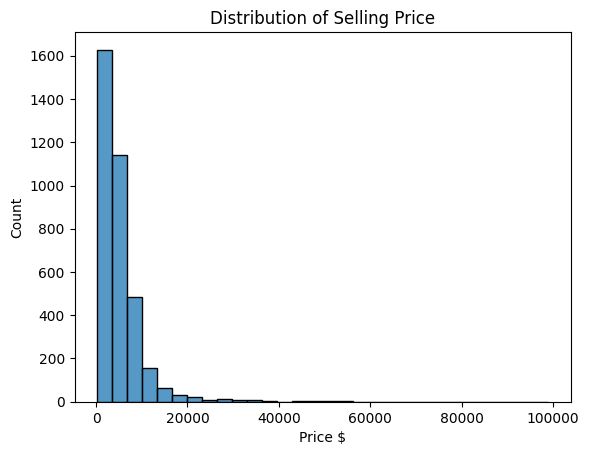

In [14]:
sns.histplot(df["selling_price"], bins=30)
plt.title("Distribution of Selling Price")
plt.xlabel("Price $")
plt.show()

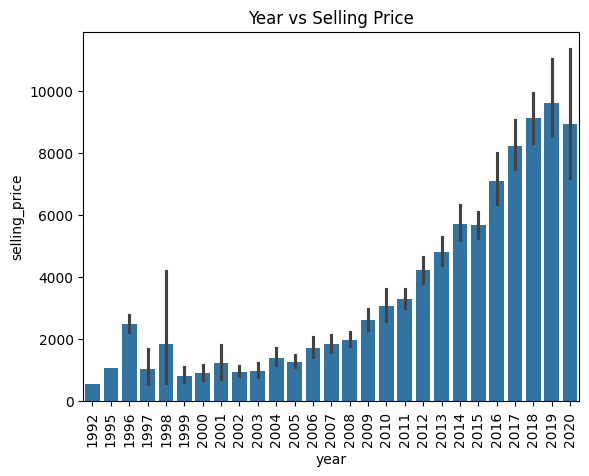

In [15]:
sns.barplot(
    data=df,
    x="year",
    y="selling_price"
)

plt.title("Year vs Selling Price")
plt.xticks(rotation=90)
plt.show()

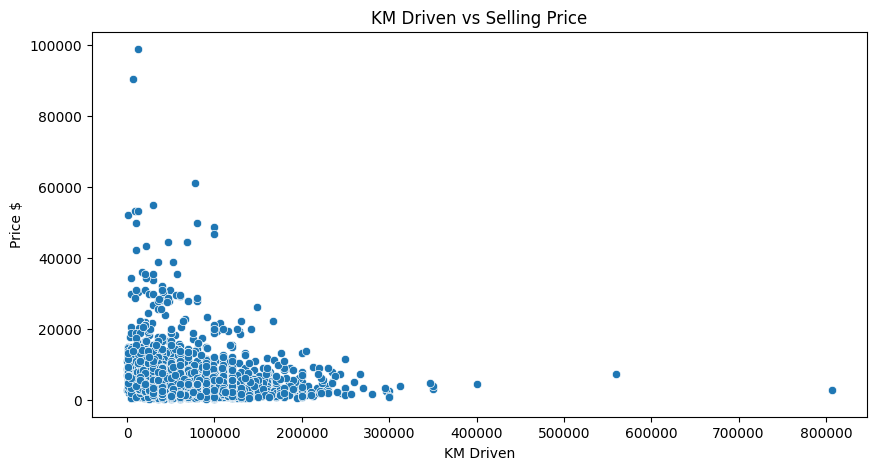

In [16]:
plt.figure(figsize=(10, 5))

sns.scatterplot(
    data=df,
    x="km_driven",
    y="selling_price"
)

plt.title("KM Driven vs Selling Price")
plt.xlabel("KM Driven")
plt.ylabel("Price $")
plt.show()

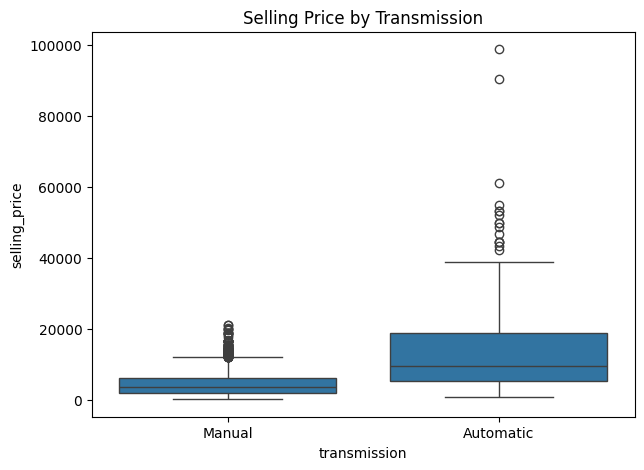

In [17]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    data=df,
    x="transmission",
    y="selling_price"
)

plt.title("Selling Price by Transmission")
plt.show()

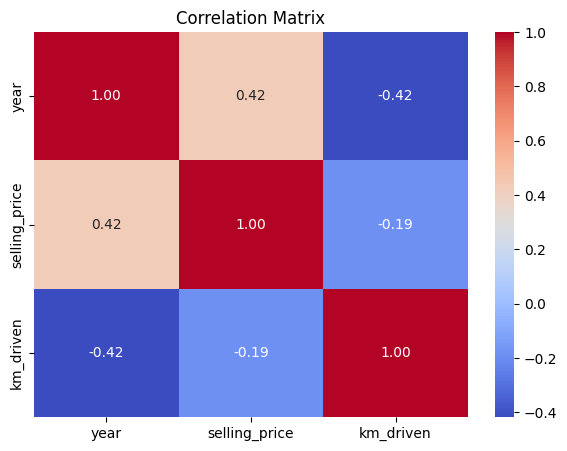

In [18]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

## Feature Engineering

In [19]:
# Lets take out the company name into a new column
df["company"] = df["name"].str.split().str[0]
df["model"] = df["name"].str.split().str[1:].str.join(" ")
df = df.drop(columns="name")
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,company,model
0,2007,667.0,70000,Petrol,Individual,Manual,First Owner,Maruti,800 AC
1,2007,1500.0,50000,Petrol,Individual,Manual,First Owner,Maruti,Wagon R LXI Minor
2,2012,6667.0,100000,Diesel,Individual,Manual,First Owner,Hyundai,Verna 1.6 SX
3,2017,2778.0,46000,Petrol,Individual,Manual,First Owner,Datsun,RediGO T Option
4,2014,5000.0,141000,Diesel,Individual,Manual,Second Owner,Honda,Amaze VX i-DTEC


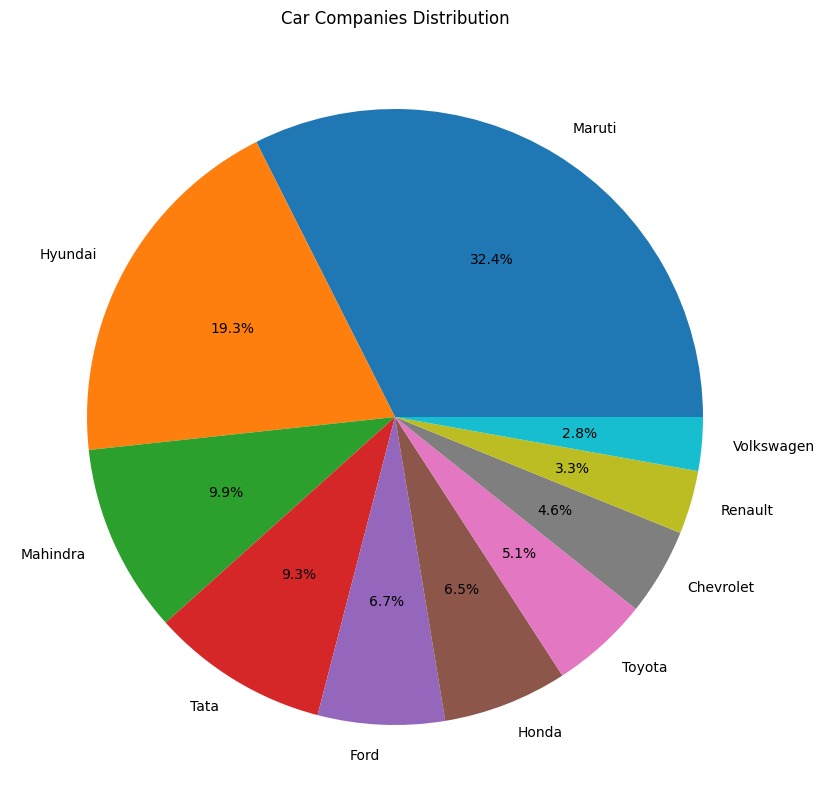

In [20]:
df["company"].value_counts().head(10).plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(10, 10)
)

plt.title("Car Companies Distribution")
plt.ylabel("")
plt.show()

## Prepare the data to ML

In [21]:
X = df.drop("selling_price", axis=1)
y = df["selling_price"]

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2 ,random_state=1)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(2861, 8)
(716, 8)
(2861,)
(716,)


In [23]:
categorical_cols = ["fuel", "seller_type", "transmission", "owner", "company", "model"]
numerical_cols = ["year", "km_driven"]

In [24]:
preprocessor = ColumnTransformer([("num", StandardScaler(), numerical_cols),
                                  ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)])

In [25]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

## Linear Regression Model

In [26]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1440.0790550830743
RMSE: 3181.6115551012094
R2: 0.747807982967908


## Random Forest Model

In [27]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1468.2602194400106
RMSE: 3439.507085066139
R2: 0.7052665407399688


## Gradient Boosting Model

In [28]:
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1679.233499908354
RMSE: 3253.838353379553
R2: 0.736227829834809


## Cat Boost Model

In [29]:
cat_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    verbose=0
)

cat_model.fit(
    X_train,
    y_train
)

y_pred_cat = cat_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_cat)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_cat))
r2 = r2_score(y_test, y_pred_cat)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1549.4451762423798
RMSE: 3132.267249381794
R2: 0.7555699234575393


In [30]:
import joblib
import json

# Save the fitted preprocessor and the trained CatBoost model
joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(cat_model, "cat_model.pkl")

# Save dropdown options + valid ranges so the app UI matches training data
options = {
    "companies": sorted(df["company"].unique().tolist()),
    "models_by_company": {
        company: sorted(df[df["company"] == company]["model"].unique().tolist())
        for company in df["company"].unique()
    },
    "fuel": sorted(df["fuel"].unique().tolist()),
    "seller_type": sorted(df["seller_type"].unique().tolist()),
    "transmission": sorted(df["transmission"].unique().tolist()),
    "owner": sorted(df["owner"].unique().tolist()),
    "year_min": int(df["year"].min()),
    "year_max": int(df["year"].max()),
    "km_driven_min": int(df["km_driven"].min()),
    "km_driven_max": int(df["km_driven"].max()),
}

with open("options.json", "w") as f:
    json.dump(options, f, indent=2)

print("Saved: preprocessor.pkl, cat_model.pkl, options.json")

# Download the 3 files
from google.colab import files
files.download("preprocessor.pkl")
files.download("cat_model.pkl")
files.download("options.json")

Saved: preprocessor.pkl, cat_model.pkl, options.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Predict on New Data

In [31]:
# Enter your own car details here to get a predicted selling price
new_car = {
    "year": 2015,
    "km_driven": 50000,
    "fuel": "Petrol",
    "seller_type": "Individual",
    "transmission": "Manual",
    "owner": "First Owner",
    "company": "Maruti",
    "model": "800 AC"
}

new_df = pd.DataFrame([new_car])

new_X = preprocessor.transform(new_df)

predicted_price = cat_model.predict(new_X)
print("Predicted selling price:", predicted_price[0])


Predicted selling price: 3781.359969924472
